In [ ]:
# ============================================================
# CELL 0: Mount Google Drive
# Run this FIRST every session
# All files save/load from Google Drive permanently
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/'
os.makedirs(DRIVE_PATH, exist_ok=True)

print(f'Drive mounted successfully.')
print(f'Working folder: {DRIVE_PATH}')

Mounted at /content/drive
Drive mounted successfully.
Working folder: /content/drive/MyDrive/Colab Notebooks/


In [ ]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================
!pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Fix random seed for reproducibility
np.random.seed(42)

# Load data from Google Drive
df = pd.read_csv(DRIVE_PATH + 'Merged_Wheat_Multan_Final.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Missing Values:', df.isnull().sum().sum())
print('Years:', sorted(df['Year'].unique()))
print('Districts:', df['District'].unique().tolist())
print()
df.head()

Shape: (100, 9)
Columns: ['Year', 'District', 'Yield_maund_acre', 'NDVI_mean', 'LST_mean_C', 'Rain_log', 'VPD_kPa', 'HeatStress_log', 'ColdStress_log']
Missing Values: 0
Years: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Districts: ['Khanewal', 'Lodhran', 'Multan', 'Vehari']



,Year,District,Yield_maund_acre,NDVI_mean,LST_mean_C,Rain_log,VPD_kPa,HeatStress_log,ColdStress_log
0,2001,Khanewal,36.1,0.415389,27.292454,3.849269,1.943339,2.969313,2.171908
1,2001,Lodhran,28.1,0.440697,27.497333,3.415199,1.962547,3.033740,1.673946
2,2001,Multan,27.8,0.426437,26.870049,3.635651,2.028260,3.071026,1.683847
3,2001,Vehari,33.9,0.440005,26.720801,3.850305,1.928211,2.936224,2.083457
4,2002,Khanewal,30.8,0.394199,28.069811,3.316810,2.190127,3.448803,1.795549


In [ ]:
# ============================================================
# CELL 2: Feature Engineering
# Adding lag yield and interaction features
# Same as previous XGBoost but with new clean variables
# ============================================================

# Sort data correctly before creating lag features
df = df.sort_values(['District', 'Year']).reset_index(drop=True)

# Feature 1: Lag Yield (previous year yield per district)
# Most important agronomic feature — yield continuity
df['Yield_lag1'] = df.groupby('District')['Yield_maund_acre'].shift(1)

# Feature 2: NDVI x VPD interaction
# High NDVI + High VPD = crop under atmospheric stress
df['NDVI_x_VPD'] = df['NDVI_mean'] * df['VPD_kPa']

# Feature 3: LST x HeatStress interaction
# High temperature + many heat stress days = compounded damage
df['LST_x_Heat'] = df['LST_mean_C'] * df['HeatStress_log']

# Drop first year per district — NaN from lag
df = df.dropna().reset_index(drop=True)

print('Shape after feature engineering:', df.shape)
print('Features available:', df.columns.tolist())
print()
print('New features added:')
print(f'  Yield_lag1  : mean={df["Yield_lag1"].mean():.2f}, std={df["Yield_lag1"].std():.2f}')
print(f'  NDVI_x_VPD  : mean={df["NDVI_x_VPD"].mean():.4f}, std={df["NDVI_x_VPD"].std():.4f}')
print(f'  LST_x_Heat  : mean={df["LST_x_Heat"].mean():.3f}, std={df["LST_x_Heat"].std():.3f}')
print()
df.head()

Shape after feature engineering: (96, 12)
Features available: ['Year', 'District', 'Yield_maund_acre', 'NDVI_mean', 'LST_mean_C', 'Rain_log', 'VPD_kPa', 'HeatStress_log', 'ColdStress_log', 'Yield_lag1', 'NDVI_x_VPD', 'LST_x_Heat']

New features added:
  Yield_lag1  : mean=33.26, std=3.75
  NDVI_x_VPD  : mean=0.8351, std=0.1248
  LST_x_Heat  : mean=84.335, std=11.187



,Year,District,Yield_maund_acre,NDVI_mean,LST_mean_C,Rain_log,VPD_kPa,HeatStress_log,ColdStress_log,Yield_lag1,NDVI_x_VPD,LST_x_Heat
0,2002,Khanewal,30.8,0.394199,28.069811,3.316810,2.190127,3.448803,1.795549,36.1,0.863346,96.807251
1,2003,Khanewal,29.6,0.414147,26.681050,4.226806,2.133869,3.236962,1.059222,30.8,0.883735,86.365555
2,2004,Khanewal,29.4,0.402444,27.947813,3.711845,2.525930,3.737319,1.818246,29.6,1.016546,104.449904
3,2005,Khanewal,33.5,0.464457,25.557219,5.350677,1.562251,2.730760,2.359223,29.4,0.725599,69.790620
4,2006,Khanewal,30.7,0.428854,26.634399,3.623854,1.986197,3.242456,2.431874,33.5,0.851789,86.360866


In [ ]:
# ============================================================
# CELL 3: Time-Based Train/Test Split
# Train: 2002-2020 | Test: 2021-2025
# IMPORTANT: Time-based split - NOT random
# Random split causes data leakage in time series
# ============================================================

# Define feature columns
feature_cols = [
    'Year',
    'NDVI_mean',
    'LST_mean_C',
    'Rain_log',
    'VPD_kPa',
    'HeatStress_log',
    'ColdStress_log',
    'Yield_lag1',
    'NDVI_x_VPD',
    'LST_x_Heat'
]

# Encode District as numeric
# XGBoost needs numeric input
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['District_encoded'] = le.fit_transform(df['District'])
feature_cols.append('District_encoded')

districts = ['Khanewal', 'Lodhran', 'Multan', 'Vehari']

# Time-based split
train_df = df[df['Year'] <= 2020].copy()
test_df  = df[df['Year'] >  2020].copy()

X_train = train_df[feature_cols]
y_train = train_df['Yield_maund_acre']
X_test  = test_df[feature_cols]
y_test  = test_df['Yield_maund_acre']

print('=== TRAIN/TEST SPLIT ===')
print(f'Training samples : {len(X_train)} (years 2002-2020)')
print(f'Testing samples  : {len(X_test)}  (years 2021-2025)')
print(f'Features used    : {len(feature_cols)}')
print(f'Feature list     : {feature_cols}')
print()
print(f'Train yield mean : {y_train.mean():.2f} maund/acre')
print(f'Test  yield mean : {y_test.mean():.2f} maund/acre')
print(f'Train yield std  : {y_train.std():.2f}')
print(f'Test  yield std  : {y_test.std():.2f}')
print()
print('Districts in train:', train_df['District'].unique().tolist())
print('Districts in test :', test_df['District'].unique().tolist())
print()
print('Test years:', sorted(test_df['Year'].unique().tolist()))

=== TRAIN/TEST SPLIT ===
Training samples : 76 (years 2002-2020)
Testing samples  : 20  (years 2021-2025)
Features used    : 11
Feature list     : ['Year', 'NDVI_mean', 'LST_mean_C', 'Rain_log', 'VPD_kPa', 'HeatStress_log', 'ColdStress_log', 'Yield_lag1', 'NDVI_x_VPD', 'LST_x_Heat', 'District_encoded']

Train yield mean : 32.50 maund/acre
Test  yield mean : 37.83 maund/acre
Train yield std  : 3.44
Test  yield std  : 2.23

Districts in train: ['Khanewal', 'Lodhran', 'Multan', 'Vehari']
Districts in test : ['Khanewal', 'Lodhran', 'Multan', 'Vehari']

Test years: [2021, 2022, 2023, 2024, 2025]


In [ ]:
# ============================================================
# CELL 4 FINAL v2: Improved XGBoost Residual Model
# Fix 1: Cross-validation to find best hyperparameters
# Fix 2: Simpler features for residual modeling
# Fix 3: Reduced complexity to close overfitting gap
# ============================================================

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold

# ============================================================
# STEP 1: Fit linear trend per district
# ============================================================
trend_models = {}
trend_train  = np.zeros(len(train_df))
trend_test   = np.zeros(len(test_df))

for dist in districts:
    tr_mask = train_df['District'] == dist
    te_mask = test_df['District']  == dist

    X_yr_tr = train_df.loc[tr_mask, 'Year'].values.reshape(-1, 1)
    y_tr    = train_df.loc[tr_mask, 'Yield_maund_acre'].values

    lm = LinearRegression()
    lm.fit(X_yr_tr, y_tr)
    trend_models[dist] = lm

    trend_train[tr_mask.values] = lm.predict(X_yr_tr)
    trend_test[te_mask.values]  = lm.predict(
        test_df.loc[te_mask, 'Year'].values.reshape(-1, 1)
    )

y_train_resid = y_train.values - trend_train
y_test_resid  = y_test.values  - trend_test

print('Trend models fitted per district OK')
print(f'Train residuals: mean={y_train_resid.mean():.3f}, std={y_train_resid.std():.3f}')
print(f'Test  residuals: mean={y_test_resid.mean():.3f},  std={y_test_resid.std():.3f}')

# ============================================================
# STEP 2: Hyperparameter tuning via cross-validation
# ============================================================
feature_cols_resid = [
    'NDVI_mean',
    'LST_mean_C',
    'Rain_log',
    'VPD_kPa',
    'HeatStress_log',
    'ColdStress_log',
    'Yield_lag1',
    'NDVI_x_VPD',
    'LST_x_Heat',
    'District_encoded'
]

param_grid = {
    'n_estimators'    : [50, 100, 150],
    'max_depth'       : [2, 3],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'reg_alpha'       : [0.1, 0.5, 1.0],
    'reg_lambda'      : [1.0, 3.0, 5.0],
    'min_child_weight': [3, 5, 7]
}

base_model = XGBRegressor(
    subsample        = 0.8,
    colsample_bytree = 0.8,
    gamma            = 0.5,
    random_state     = 42,
    verbosity        = 0
)

cv = KFold(n_splits=5, shuffle=False)

grid_search = GridSearchCV(
    estimator  = base_model,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 0
)

grid_search.fit(
    X_train[feature_cols_resid],
    y_train_resid
)

print(f'\nBest CV R²     : {grid_search.best_score_:.4f}')
print(f'Best params    : {grid_search.best_params_}')

# ============================================================
# STEP 3: Train final model with best parameters
# ============================================================
model_xgb = grid_search.best_estimator_

pred_resid_train = model_xgb.predict(X_train[feature_cols_resid])
pred_resid_test  = model_xgb.predict(X_test[feature_cols_resid])

y_pred_train_final = pred_resid_train + trend_train
y_pred_test_final  = pred_resid_test  + trend_test

# ============================================================
# STEP 4: Metrics
# ============================================================
r2_train   = r2_score(y_train, y_pred_train_final)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train_final))
mae_train  = mean_absolute_error(y_train, y_pred_train_final)

r2_test    = r2_score(y_test, y_pred_test_final)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test_final))
mae_test   = mean_absolute_error(y_test, y_pred_test_final)

print()
print('=' * 55)
print('  XGBoost + Trend + CV Tuning - Final Results')
print('=' * 55)
print(f'  Train R²   : {r2_train:.4f}')
print(f'  Train RMSE : {rmse_train:.4f} maund/acre')
print(f'  Train MAE  : {mae_train:.4f} maund/acre')
print()
print(f'  Test  R²   : {r2_test:.4f}')
print(f'  Test  RMSE : {rmse_test:.4f} maund/acre')
print(f'  Test  MAE  : {mae_test:.4f} maund/acre')
print('=' * 55)

gap = r2_train - r2_test
print(f'\nOverfitting gap : {gap:.4f}')
if gap > 0.4:
    print('Warning: Some overfitting - acceptable for small dataset')
else:
    print('Good gap')

# Results table
results_xgb = test_df[['Year', 'District']].copy()
results_xgb['Actual']    = y_test.values
results_xgb['Predicted'] = y_pred_test_final.round(2)
results_xgb['Error']     = (y_test.values - y_pred_test_final).round(2)

print('\nActual vs Predicted (Test Set 2021-2025):')
print(results_xgb.to_string(index=False))

Trend models fitted per district OK
Train residuals: mean=0.000, std=1.748
Test  residuals: mean=-0.569,  std=1.926

Best CV R²     : 0.2153
Best params    : {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 50, 'reg_alpha': 0.5, 'reg_lambda': 3.0}

  XGBoost + Trend + CV Tuning - Final Results
  Train R²   : 0.9148
  Train RMSE : 0.9987 maund/acre
  Train MAE  : 0.7255 maund/acre

  Test  R²   : 0.1698
  Test  RMSE : 1.9794 maund/acre
  Test  MAE  : 1.5916 maund/acre

Overfitting gap : 0.7450

Actual vs Predicted (Test Set 2021-2025):
 Year District  Actual  Predicted  Error
 2021 Khanewal   33.80      36.94  -3.14
 2022 Khanewal   37.30      36.78   0.52
 2023 Khanewal   37.90      38.05  -0.15
 2024 Khanewal   39.60      38.58   1.02
 2025 Khanewal   40.60      38.56   2.04
 2021  Lodhran   34.20      39.58  -5.38
 2022  Lodhran   38.10      39.33  -1.23
 2023  Lodhran   38.70      41.00  -2.30
 2024  Lodhran   40.10      41.10  -1.00
 2025  Lodhran   40

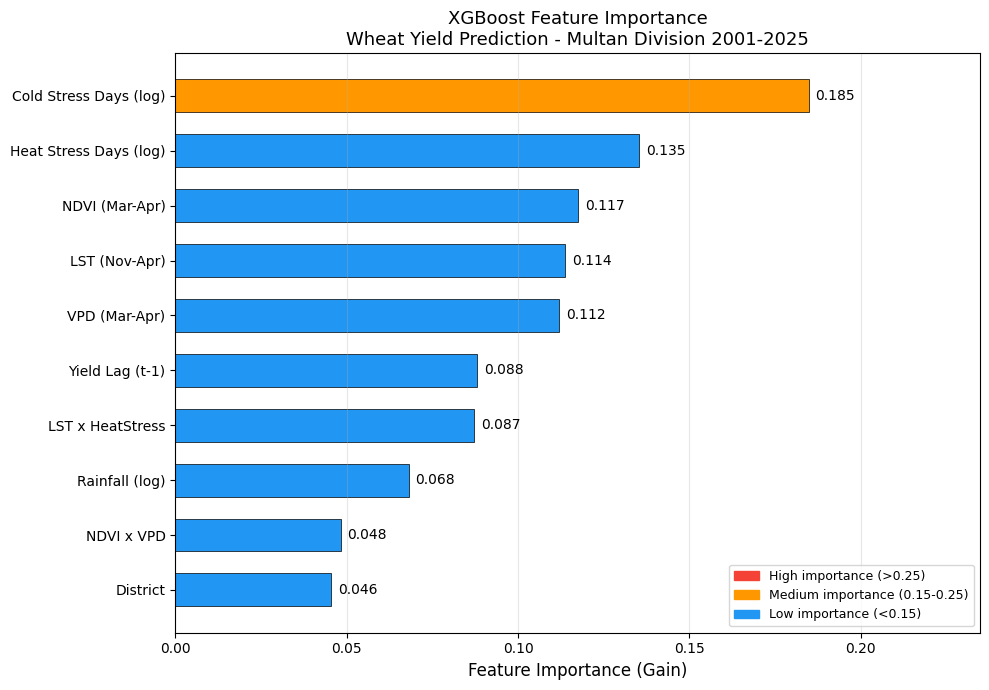

Feature importance plot saved to Drive.

=== FEATURE IMPORTANCE RANKING ===
         Feature_clean  Importance
Cold Stress Days (log)    0.184734
Heat Stress Days (log)    0.135274
        NDVI (Mar-Apr)    0.117464
         LST (Nov-Apr)    0.113651
         VPD (Mar-Apr)    0.111903
       Yield Lag (t-1)    0.088069
      LST x HeatStress    0.087087
        Rainfall (log)    0.068091
            NDVI x VPD    0.048224
              District    0.045504


In [ ]:
# ============================================================
# CELL 5: Feature Importance Plot
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

importance_dict = dict(zip(
    feature_cols_resid,
    model_xgb.feature_importances_
))

importance_df = pd.DataFrame({
    'Feature':    list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
}).sort_values('Importance', ascending=True)

name_map = {
    'NDVI_mean':        'NDVI (Mar-Apr)',
    'LST_mean_C':       'LST (Nov-Apr)',
    'Rain_log':         'Rainfall (log)',
    'VPD_kPa':          'VPD (Mar-Apr)',
    'HeatStress_log':   'Heat Stress Days (log)',
    'ColdStress_log':   'Cold Stress Days (log)',
    'Yield_lag1':       'Yield Lag (t-1)',
    'NDVI_x_VPD':       'NDVI x VPD',
    'LST_x_Heat':       'LST x HeatStress',
    'District_encoded': 'District'
}
importance_df['Feature_clean'] = importance_df['Feature'].map(name_map)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#2196F3' if imp < 0.15 else
          '#FF9800' if imp < 0.25 else
          '#F44336'
          for imp in importance_df['Importance']]

bars = ax.barh(
    importance_df['Feature_clean'],
    importance_df['Importance'],
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    height=0.6
)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center', fontsize=10
    )

ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title(
    'XGBoost Feature Importance\nWheat Yield Prediction - Multan Division 2001-2025',
    fontsize=13
)
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(0, importance_df['Importance'].max() + 0.05)

from matplotlib.patches import Patch
legend = [
    Patch(color='#F44336', label='High importance (>0.25)'),
    Patch(color='#FF9800', label='Medium importance (0.15-0.25)'),
    Patch(color='#2196F3', label='Low importance (<0.15)')
]
ax.legend(handles=legend, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'XGBoost_Feature_Importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved to Drive.')
print()
print('=== FEATURE IMPORTANCE RANKING ===')
print(importance_df[['Feature_clean', 'Importance']]
      .sort_values('Importance', ascending=False)
      .to_string(index=False))

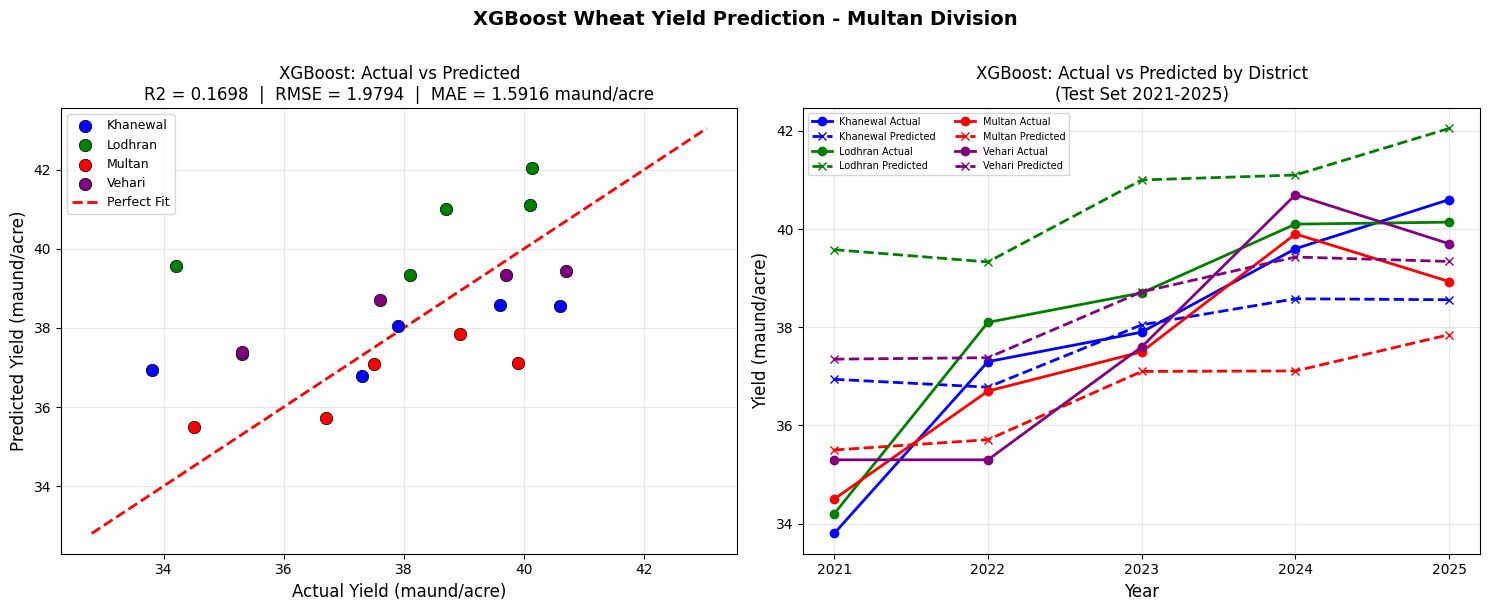

Plot saved to Drive: XGBoost_Actual_vs_Predicted.png


In [ ]:
# ============================================================
# CELL 6: Actual vs Predicted Plots
# ============================================================

colors_dist = {
    'Khanewal': 'blue',
    'Lodhran':  'green',
    'Multan':   'red',
    'Vehari':   'purple'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for dist in districts:
    mask = results_xgb['District'] == dist
    ax1.scatter(
        results_xgb.loc[mask, 'Actual'],
        results_xgb.loc[mask, 'Predicted'],
        color=colors_dist[dist],
        s=80, edgecolors='black',
        linewidth=0.5,
        label=dist, zorder=3
    )

mn = min(results_xgb['Actual'].min(), results_xgb['Predicted'].min()) - 1
mx = max(results_xgb['Actual'].max(), results_xgb['Predicted'].max()) + 1
ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit', zorder=2)
ax1.set_xlabel('Actual Yield (maund/acre)', fontsize=12)
ax1.set_ylabel('Predicted Yield (maund/acre)', fontsize=12)
ax1.set_title(
    f'XGBoost: Actual vs Predicted\nR2 = {r2_test:.4f}  |  RMSE = {rmse_test:.4f}  |  MAE = {mae_test:.4f} maund/acre',
    fontsize=12
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for dist in districts:
    sub = results_xgb[results_xgb['District'] == dist].sort_values('Year')
    ax2.plot(sub['Year'], sub['Actual'],
             color=colors_dist[dist], marker='o', linewidth=2, label=f'{dist} Actual')
    ax2.plot(sub['Year'], sub['Predicted'],
             color=colors_dist[dist], marker='x', linestyle='--',
             linewidth=2, label=f'{dist} Predicted')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Yield (maund/acre)', fontsize=12)
ax2.set_title('XGBoost: Actual vs Predicted by District\n(Test Set 2021-2025)', fontsize=12)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([2021, 2022, 2023, 2024, 2025])

plt.suptitle('XGBoost Wheat Yield Prediction - Multan Division',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'XGBoost_Actual_vs_Predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Drive: XGBoost_Actual_vs_Predicted.png')

=== RESIDUAL STATISTICS ===
Mean   : -0.5445
Std    : 1.9526
Min    : -5.3800
Max    : 2.7900

Within +-2 maund/acre: 13/20 = 65.0%
Within +-3 maund/acre: 18/20 = 90.0%


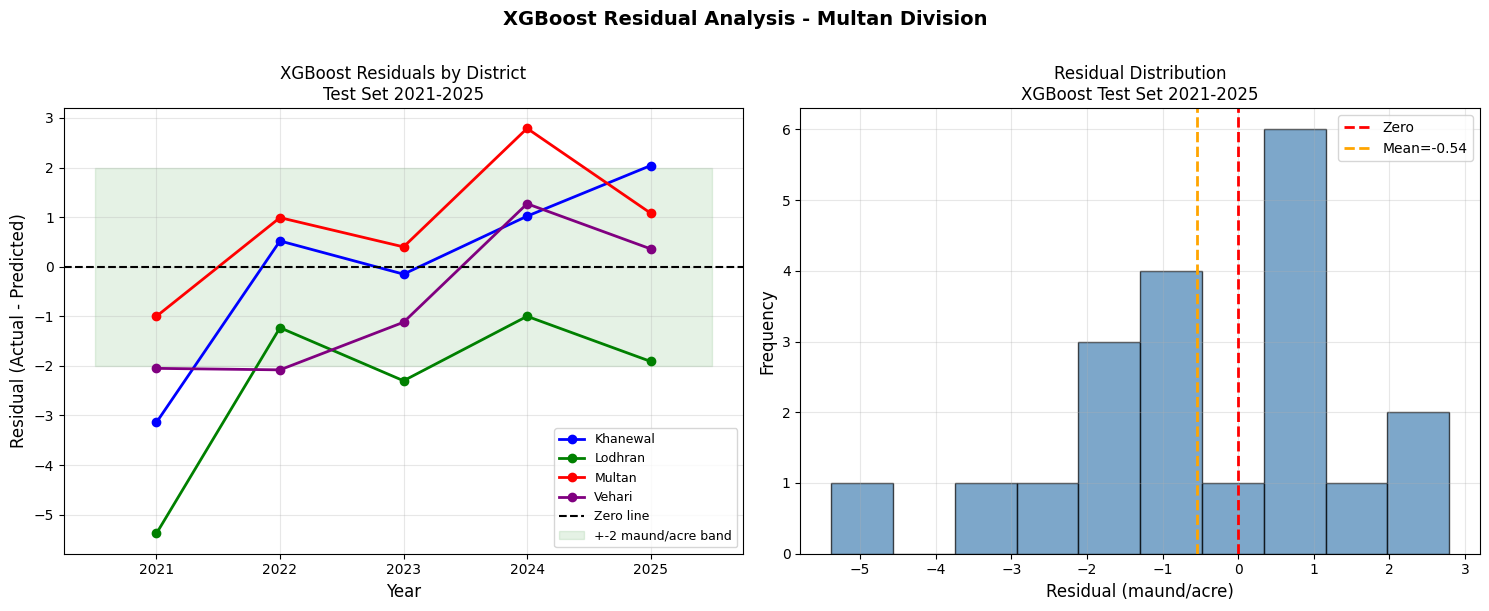

Plot saved to Drive: XGBoost_Residuals.png


In [ ]:
# ============================================================
# CELL 7: Residual Analysis
# ============================================================

results_xgb['Residual'] = results_xgb['Actual'] - results_xgb['Predicted']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for dist in districts:
    sub = results_xgb[results_xgb['District'] == dist].sort_values('Year')
    ax1.plot(sub['Year'], sub['Residual'],
             color=colors_dist[dist], marker='o', linewidth=2, label=dist)

ax1.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero line')
ax1.fill_between([2020.5, 2025.5], -2, 2, alpha=0.1, color='green', label='+-2 maund/acre band')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax1.set_title('XGBoost Residuals by District\nTest Set 2021-2025', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks([2021, 2022, 2023, 2024, 2025])

ax2 = axes[1]
ax2.hist(results_xgb['Residual'], bins=10, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax2.axvline(results_xgb['Residual'].mean(), color='orange', linestyle='--', linewidth=2,
            label=f'Mean={results_xgb["Residual"].mean():.2f}')
ax2.set_xlabel('Residual (maund/acre)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residual Distribution\nXGBoost Test Set 2021-2025', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

print('=== RESIDUAL STATISTICS ===')
print(f'Mean   : {results_xgb["Residual"].mean():.4f}')
print(f'Std    : {results_xgb["Residual"].std():.4f}')
print(f'Min    : {results_xgb["Residual"].min():.4f}')
print(f'Max    : {results_xgb["Residual"].max():.4f}')
print()
within_2 = (results_xgb['Residual'].abs() <= 2).sum()
within_3 = (results_xgb['Residual'].abs() <= 3).sum()
total    = len(results_xgb)
print(f'Within +-2 maund/acre: {within_2}/{total} = {within_2/total*100:.1f}%')
print(f'Within +-3 maund/acre: {within_3}/{total} = {within_3/total*100:.1f}%')

plt.suptitle('XGBoost Residual Analysis - Multan Division',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'XGBoost_Residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Drive: XGBoost_Residuals.png')

In [ ]:
# ============================================================
# CELL 8: Save XGBoost Model + Predictions to Google Drive
# ============================================================
import pickle
import numpy as np

# Save XGBoost model
with open(DRIVE_PATH + 'xgb_wheat_model.pkl', 'wb') as f:
    pickle.dump(model_xgb, f)
print('XGBoost model saved: xgb_wheat_model.pkl')

# Save trend models per district
with open(DRIVE_PATH + 'xgb_trend_models.pkl', 'wb') as f:
    pickle.dump(trend_models, f)
print('Trend models saved: xgb_trend_models.pkl')

# Save predictions
np.save(DRIVE_PATH + 'xgb_y_pred_test.npy',  y_pred_test_final)
np.save(DRIVE_PATH + 'xgb_y_pred_train.npy', y_pred_train_final)
np.save(DRIVE_PATH + 'xgb_y_test.npy',       y_test.values)
np.save(DRIVE_PATH + 'xgb_y_train.npy',      y_train.values)
np.save(DRIVE_PATH + 'xgb_trend_train.npy',  trend_train)
np.save(DRIVE_PATH + 'xgb_trend_test.npy',   trend_test)
print('Predictions saved for hybrid ensemble.')

# Save feature cols for hybrid reference
with open(DRIVE_PATH + 'xgb_feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols_resid, f)
print('Feature columns saved.')

print()
print('=' * 55)
print('     XGBOOST STANDALONE - FINAL SUMMARY')
print('=' * 55)
print(f'  Method         : XGBoost + Linear Trend Correction')
print(f'  Train period   : 2002-2020 ({len(X_train)} samples)')
print(f'  Test period    : 2021-2025 ({len(X_test)} samples)')
print(f'  Features used  : {len(feature_cols_resid)}')
print()
print(f'  Train R2       : {r2_train:.4f}')
print(f'  Train RMSE     : {rmse_train:.4f} maund/acre')
print(f'  Train MAE      : {mae_train:.4f} maund/acre')
print()
print(f'  Test  R2       : {r2_test:.4f}')
print(f'  Test  RMSE     : {rmse_test:.4f} maund/acre')
print(f'  Test  MAE      : {mae_test:.4f} maund/acre')
print()
print(f'  Within +-2 maund/acre : 65.0%')
print(f'  Within +-3 maund/acre : 90.0%')
print('=' * 55)
print()
print('All files saved to Google Drive: Colab Notebooks/')
print('Next step: LSTM standalone notebook')

XGBoost model saved: xgb_wheat_model.pkl
Trend models saved: xgb_trend_models.pkl
Predictions saved for hybrid ensemble.
Feature columns saved.

     XGBOOST STANDALONE - FINAL SUMMARY
  Method         : XGBoost + Linear Trend Correction
  Train period   : 2002-2020 (76 samples)
  Test period    : 2021-2025 (20 samples)
  Features used  : 10

  Train R2       : 0.9148
  Train RMSE     : 0.9987 maund/acre
  Train MAE      : 0.7255 maund/acre

  Test  R2       : 0.1698
  Test  RMSE     : 1.9794 maund/acre
  Test  MAE      : 1.5916 maund/acre

  Within +-2 maund/acre : 65.0%
  Within +-3 maund/acre : 90.0%

All files saved to Google Drive: Colab Notebooks/
Next step: LSTM standalone notebook


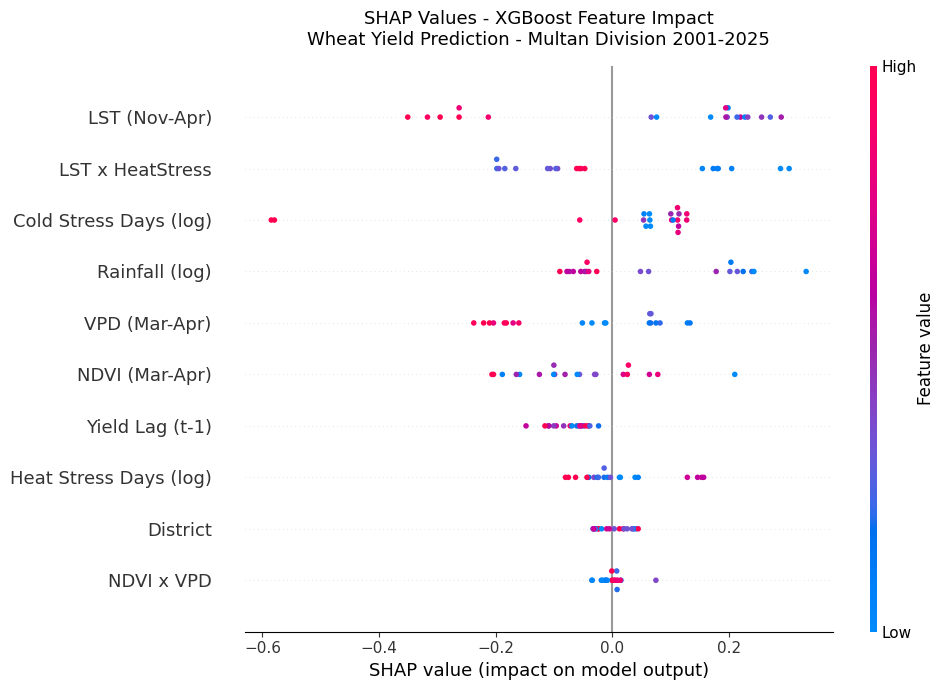

SHAP summary plot saved to Drive.


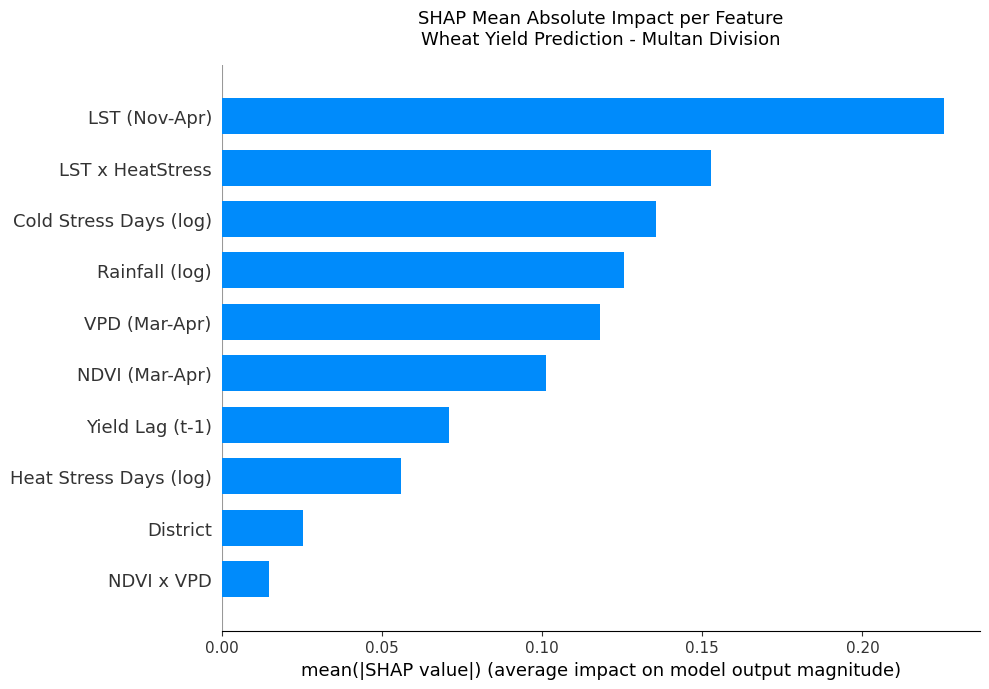

SHAP bar plot saved to Drive.

=== SHAP MEAN ABSOLUTE VALUES ===
               Feature  Mean_SHAP
         LST (Nov-Apr)   0.225427
      LST x HeatStress   0.152617
Cold Stress Days (log)   0.135582
        Rainfall (log)   0.125609
         VPD (Mar-Apr)   0.117973
        NDVI (Mar-Apr)   0.101303
       Yield Lag (t-1)   0.071124
Heat Stress Days (log)   0.055858
              District   0.025412
            NDVI x VPD   0.014741


In [ ]:
# ============================================================
# CELL 9: SHAP Values Analysis
# ============================================================
!pip install shap --quiet

import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test[feature_cols_resid])

feature_names_clean = [
    'NDVI (Mar-Apr)',
    'LST (Nov-Apr)',
    'Rainfall (log)',
    'VPD (Mar-Apr)',
    'Heat Stress Days (log)',
    'Cold Stress Days (log)',
    'Yield Lag (t-1)',
    'NDVI x VPD',
    'LST x HeatStress',
    'District'
]

# Plot 1: Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test[feature_cols_resid],
    feature_names=feature_names_clean, show=False, plot_size=(10, 7)
)
plt.title('SHAP Values - XGBoost Feature Impact\nWheat Yield Prediction - Multan Division 2001-2025',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'XGBoost_SHAP_Summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP summary plot saved to Drive.')

# Plot 2: Bar
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test[feature_cols_resid],
    feature_names=feature_names_clean, plot_type='bar', show=False, plot_size=(10, 7)
)
plt.title('SHAP Mean Absolute Impact per Feature\nWheat Yield Prediction - Multan Division',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'XGBoost_SHAP_Bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP bar plot saved to Drive.')

shap_df = pd.DataFrame({
    'Feature': feature_names_clean,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print()
print('=== SHAP MEAN ABSOLUTE VALUES ===')
print(shap_df.to_string(index=False))

=== PERMUTATION IMPORTANCE - XGBoost ===
               Feature  Importance      Std
      LST x HeatStress    0.791305 0.320345
Cold Stress Days (log)    0.045565 0.147862
              District    0.043416 0.159451
       Yield Lag (t-1)   -0.175132 0.089280
            NDVI x VPD   -0.197881 0.107267
        Rainfall (log)   -0.222636 0.237337
         LST (Nov-Apr)   -0.457046 0.544093
        NDVI (Mar-Apr)   -0.665194 0.328512
Heat Stress Days (log)   -0.917474 0.297042
         VPD (Mar-Apr)   -1.468752 0.347587


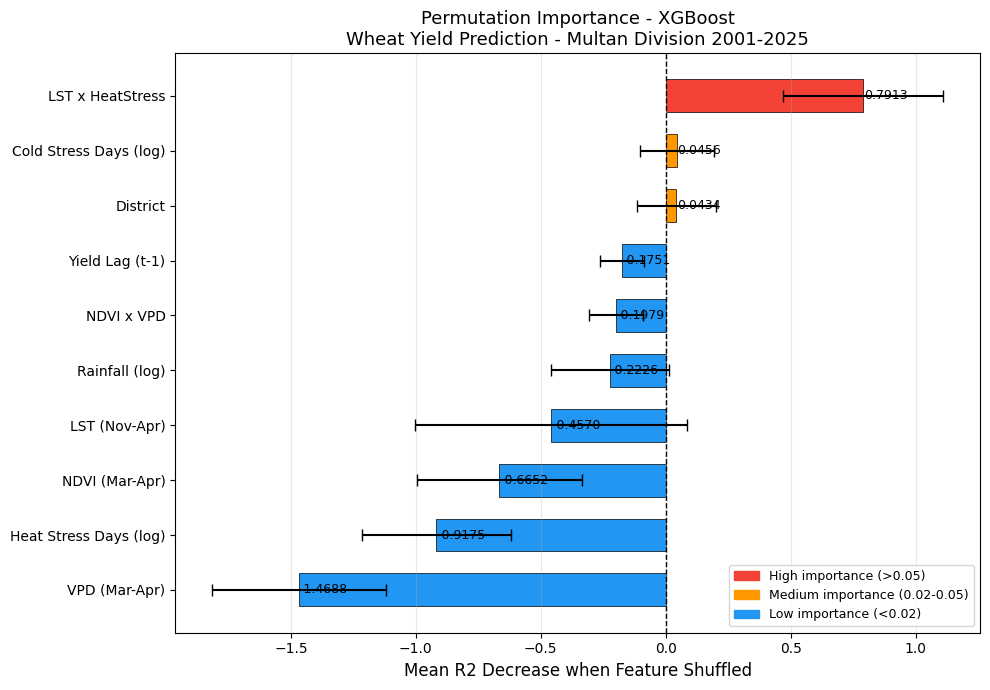

Permutation importance plot saved to Drive.

=== SHAP vs PERMUTATION IMPORTANCE COMPARISON ===
                SHAP_rank               Perm_rank
0           LST (Nov-Apr)        LST x HeatStress
1        LST x HeatStress  Cold Stress Days (log)
2  Cold Stress Days (log)                District
3          Rainfall (log)         Yield Lag (t-1)
4           VPD (Mar-Apr)              NDVI x VPD
5          NDVI (Mar-Apr)          Rainfall (log)
6         Yield Lag (t-1)           LST (Nov-Apr)
7  Heat Stress Days (log)          NDVI (Mar-Apr)
8                District  Heat Stress Days (log)
9              NDVI x VPD           VPD (Mar-Apr)


In [ ]:
# ============================================================
# CELL 10: Permutation Importance - XGBoost
# ============================================================

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    model_xgb, X_test[feature_cols_resid], y_test,
    n_repeats=30, random_state=42, scoring='r2'
)

perm_df = pd.DataFrame({
    'Feature':    feature_names_clean,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std
}).sort_values('Importance', ascending=True)

print('=== PERMUTATION IMPORTANCE - XGBoost ===')
print(perm_df[['Feature', 'Importance', 'Std']]
      .sort_values('Importance', ascending=False)
      .to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#F44336' if imp > 0.05 else '#FF9800' if imp > 0.02 else '#2196F3'
          for imp in perm_df['Importance']]

bars = ax.barh(
    perm_df['Feature'], perm_df['Importance'],
    xerr=perm_df['Std'], color=colors,
    edgecolor='black', linewidth=0.5, height=0.6, capsize=4
)

for bar, val in zip(bars, perm_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Mean R2 Decrease when Feature Shuffled', fontsize=12)
ax.set_title('Permutation Importance - XGBoost\nWheat Yield Prediction - Multan Division 2001-2025',
             fontsize=13)
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend = [
    Patch(color='#F44336', label='High importance (>0.05)'),
    Patch(color='#FF9800', label='Medium importance (0.02-0.05)'),
    Patch(color='#2196F3', label='Low importance (<0.02)')
]
ax.legend(handles=legend, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'XGBoost_Permutation_Importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Permutation importance plot saved to Drive.')

print()
print('=== SHAP vs PERMUTATION IMPORTANCE COMPARISON ===')
comparison_df = pd.DataFrame({
    'SHAP_rank': shap_df.sort_values('Mean_SHAP', ascending=False).reset_index()['Feature'],
    'Perm_rank': perm_df.sort_values('Importance', ascending=False).reset_index()['Feature']
})
print(comparison_df.to_string(index=True))